In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [ ]:
"""
Question 1 :
An airline tracks flight delays (in minutes) for 20 flights. 
Analyze the flight delays to calculate percentiles, detect outliers, and evaluate the overall distribution.
DataSet:
delays = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50,
          120, 80, 10, 75, 90, 200, 55, 40, 70, 150]
Expected Output:

Percentiles (10th, 25th, 50th, 75th, 90th): [ 14.5   28.75  52.5   82.5  123.  ]
IQR: 53.75
Outliers: [200]
"""

In [ ]:
delays = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50, 120, 80, 10, 75, 90, 200, 55, 40, 70, 150]

In [23]:
sorted_delays = sorted(delays)
total_delays = len(sorted_delays)
percentiles = [10, 25, 50, 75, 90]
per_values = []

for value in percentiles:
    per_values.append(np.percentile(sorted_delays, value).item())

q3 = per_values[percentiles.index(75)]
q1 = per_values[percentiles.index(25)]

iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
higher_bound = q3 + (1.5 * iqr)

outliers = [x  for x in sorted_delays if x < lower_bound or x > higher_bound]

print(f"Percentiles {percentiles}: ", per_values)
print("IQR: ", iqr)
print("Outliers: ", outliers)

Percentiles [10, 25, 50, 75, 90]:  [14.5, 28.75, 52.5, 82.5, 123.00000000000004]
IQR:  53.75
Outliers:  [200]


In [ ]:
"""
Question 2 :
A company wants to analyze the salary distribution of its employees to understand the central tendency
and determine whether the data is skewed.
DataSet:
salaries = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]
Expected Output:
Mean Salary: 56950.0
Median Salary: 57500.0
Mode Salary: 30000
The data is Left Skewed (Negative Skew)
"""

Approximately symmetric / normally distributed


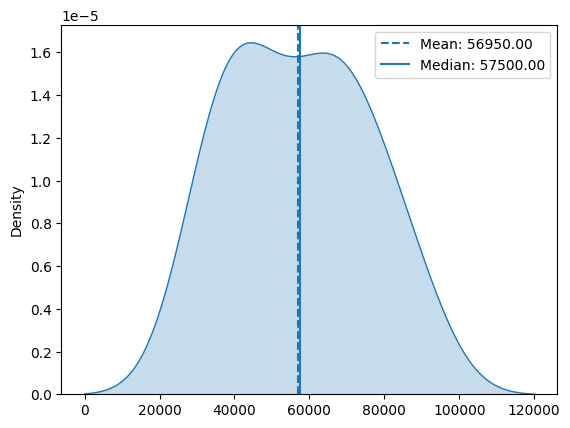

In [52]:
salaries = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]

salary_df = pd.DataFrame(salaries, columns=['Salary'])
mean = salary_df.mean()
median = salary_df.median()
mode = salary_df.mode().iloc[0]

skew_value = round(salary_df.skew().iloc[0], 2)

if skew_value > 0.5:
    result = "Right skewed (Positive skew)"
elif skew_value < -0.5:
    result = "Left skewed (Negative skew)"
elif abs(skew_value) < 0.5:
    result = "Approximately symmetric / normally distributed"
else:
    result = "Slightly skewed"

print(result)

sns.kdeplot(salary_df, fill=True)
plt.axvline(mean.item(), linestyle="--", label=f"Mean: {mean.item():.2f}")
plt.axvline(median.item(), linestyle="-", label=f"Median: {median.item():.2f}")


plt.legend()
plt.show()

In [ ]:
"""
Question 3:
 A school wants to analyze the exam performance of students across three subjects:
 Mathematics, Science, and English. 
 How can Data Science concepts be applied to understand their performance?
DataSet:
data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]
}
Expected Output:
Descriptive Statistics
Histogram(graph)
Correlation Analysis(graph)
HeatMap(graph)
"""

Descriptive Stats:         Mathematics    Science    English
count    10.000000  10.000000  10.000000
mean     81.400000  79.400000  75.700000
std      10.844353  10.895463  11.086027
min      60.000000  55.000000  50.000000
25%      76.500000  75.750000  72.500000
50%      82.500000  81.000000  77.500000
75%      89.500000  87.250000  82.250000
max      95.000000  92.000000  90.000000


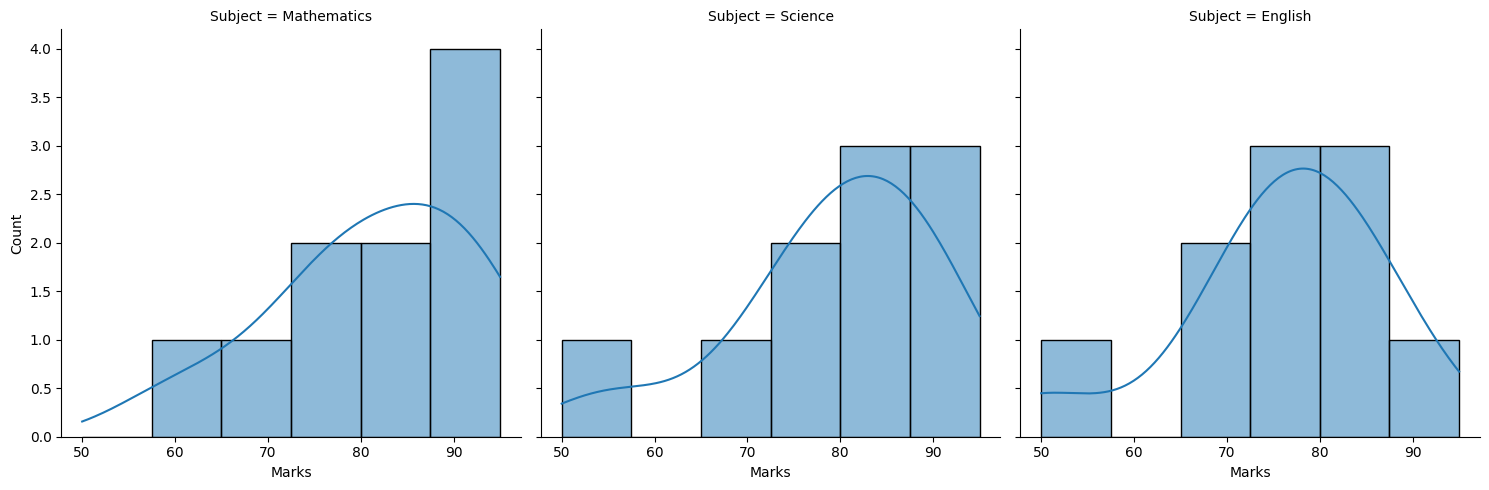


 Correlation Matrix:               Mathematics   Science   English
Mathematics     1.000000  0.792185  0.974318
Science         0.792185  1.000000  0.874999
English         0.974318  0.874999  1.000000


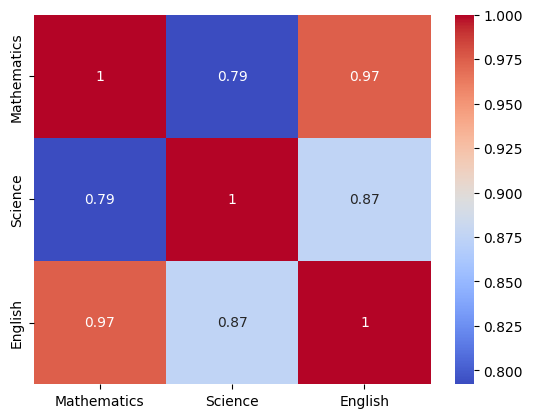

In [88]:
data = {
    "Student": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    "Mathematics": [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    "Science": [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    "English": [78, 74, 85, 80, 68, 90, 50, 77, 83, 72],
}
student_df = pd.DataFrame(data)

# descriptive statistics
print("Descriptive Stats: ", student_df.describe())

# Visualization -> Distribution plot with histogram
student_melt = student_df[["Mathematics", "Science", "English"]].melt(
    var_name="Subject", value_name="Marks"
)
sns.displot(data=student_melt, x="Marks", col="Subject", kde=True)
plt.show()

# Correlation analysis
corr_matrix = student_df.drop("Student", axis=1).corr()
print("\n Correlation Matrix: ", corr_matrix)

# heatmap => correlation visualization
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
"""
Question 4:
A pharmaceutical company conducted a clinical trial with two groups: 
one receiving medication and the other a placebo. 
How do you perform a hypothesis test to determine the effectiveness of the medication?

Dataset:
medication_group = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo_group = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]

Expected Output:
T-Statistic: -9.201427649220966
P-Value: 3.163912817600812e-08
Reject the null hypothesis: The medication is effective.
"""

In [94]:
medication_group = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo_group = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]

# perform independent t-test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(medication_group, placebo_group)
print("T-Statistic: ", t_stat)
print("P-value: ", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: The medication is effective")
else:
    print("Fail to reject null hypothesis: There is no significant difference")

T-Statistic:  -9.201427649220966
P-value:  3.163912817600807e-08
Reject the null hypothesis: The medication is effective


In [ ]:
"""
Question 5 : A company conducted a customer satisfaction survey 
where customers rated their experience on a scale of 1 to 10. 
Analyze the survey results to calculate descriptive statistics and 
visualize the distribution of customer satisfaction ratings.
Sample DataSet:  
ratings = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8, 
           6, 9, 10, 5, 8, 7, 6, 9, 10, 7]
Expected Output:
Mean Rating: 7.5
Median Rating: 7.5
Mode Rating: 7
Standard Deviation: 1.746424919657298
"""

Mean Rating:  7.5
Median Rating:  7.5
Mode Rating:  7
Standard Deviation:  1.746424919657298


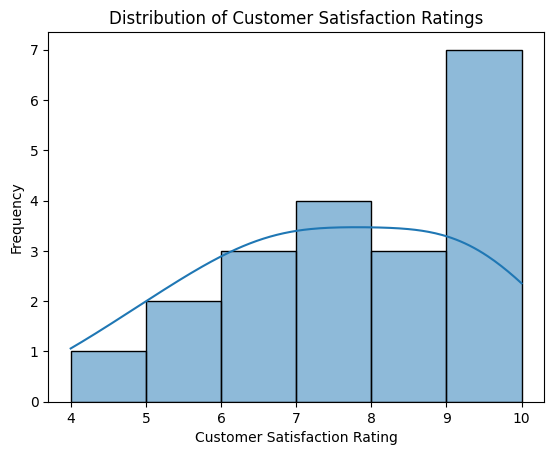

In [106]:
ratings = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8, 6, 9, 10, 5, 8, 7, 6, 9, 10, 7]
mean = np.mean(ratings)
median = np.median(ratings)
std = np.std(ratings)

value, counts = np.unique(ratings, return_counts=True)
mode = value[np.argmax(counts)]

print("Mean Rating: ", mean)
print("Median Rating: ", median)
print("Mode Rating: ", mode)
print("Standard Deviation: ", std)

sns.histplot(ratings, kde=True)
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Satisfaction Ratings')
plt.show()